# Liquidation Cascades — a quantitative teardown 🔬
### forced-liquidation event flag · forward-return event study · two-sample *t* · label-shuffle placebo · horizon × threshold sweep · costs · seed-robust synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We flag large forced-liquidation days, measure the *forward* return after them, and test whether it beats the unconditional baseline (the capitulation-bounce) — on a synthetic tape, because no free real forced-liquidation series exists.

> ⚠️ **Not investment advice.** This study is **synthetic-only**: the per-day forced-liquidation USD series the claim needs is a paid product (Coinglass/Amberdata) with no usable free history, so a `REAL` stamp (robust *t* ≥ 2 on a **real** tape) is unreachable and the study is capped at `WEAK`/`NONE`. Headline = the synthetic **null** world (1,500 days, frame fp `b3d7960bf851`, as-of 2026-06-30). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from liquidation_cascade import data, strategy as st

HORIZON, Q, SEED = 5, 0.95, 586

# The reproducible core is SYNTHETIC: there is no free forced-liquidation feed.
REAL = data.fetch_series(fetch=False)          # empty by design (no free tape)
HAVE_REAL = not REAL.empty

# The headline synthetic NULL world (bounce_alpha = 0 => liquidations carry no forward info).
FRAME_NULL, TRUTH = data.synthetic_series(bounce_alpha=0.0, horizon=HORIZON, seed=SEED)
print("real liquidation tape present:", HAVE_REAL, "(none is free — study is synthetic-only)")
print("synthetic null world:", len(FRAME_NULL), "days, frame fp",
      data.fingerprint(FRAME_NULL[["ret", "liq"]]))


real liquidation tape present: False (none is free — study is synthetic-only)
synthetic null world: 1500 days, frame fp b3d7960bf851


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | No free real tape → cannot earn `REAL`. Null world: event−baseline gap **-0.96%** (two-sample *t* **-0.92**, placebo *p* 0.34); sign flips across the horizon × threshold grid. |
| **Tradability** | `MIRAGE` | Unreachable paid feed; wrong-signed headline gap; even the best cut (h=5, top 1%, 15 events, *t* 1.27) is a curve-fit; net of a 20 bps round-trip. |

> 💡 In plain words: the engine works (the synthetic control proves it), but there is no free data to point it at, and a fair null shows no bounce and no stable sign.

## 1 · The claim, steelmanned

Let $L_t$ be day $t$'s forced-liquidation flow, $E_t = \mathbb{1}[L_t \ge Q_q(\text{trailing } L)]$ the *event* flag (top $1-q$ tail), and $r^{(H)}_{t} = \prod_{k=1}^{H}(1+r_{t+k})-1$ the return over the *next* $H$ days (strictly after $t$).

- **H₁ (the bounce).** $\mathbb{E}[r^{(H)} \mid E{=}1] - \mathbb{E}[r^{(H)}] > 0$ at *t* ≥ 2 (post-cascade returns beat the baseline).
- **H₂ (robustness).** The sign of H₁ is stable across $H$ and $q$.
- **H₃ (net).** H₁ survives the round-trip cost.
- **H₀ (data).** All of the above require a *real* $L_t$ series. **None is free.**

We find **H₀ binding** (synthetic-only), **H₁ not met** in the null world (gap wrong sign, *t* < 2), **H₂ rejected** (sign flips), **H₃ moot**. The positive control shows the engine *would* reject H₀-conditional-on-data if a bounce were truly there.

## 2 · So what? — what rides on each answer

The content is the **why**. The mechanism is real elsewhere: forced, liquidity-motivated selling overshoots and *reverses* in equities (Coval-Stafford 2007), and reversal premia spike when liquidity evaporates (Nagel 2012) — precisely the regime a liquidation-event filter selects. So the *prior* for a crypto capitulation-bounce is not silly. What kills the study is **H₀**: the conditioning variable (aggregate forced-liquidation USD) is a paid data product, so on a no-key stack the hypothesis is **untestable on real data**, and the honest output is the machinery + a null.

## 3 · How we'd know — the protocol

- **Event flag.** $E_t = \mathbb{1}[L_t \ge Q_q(\text{trailing 252d})]$ — a *point-in-time* trailing quantile (no future levels inform the threshold).
- **Forward return.** $r^{(H)}_t$ over days $t{+}1..t{+}H$ — the same-day cascade is excluded by construction (that crash is the event, not the bounce).
- **Event study.** Welch two-sample *t* of event vs non-event forward returns.
- **Placebo.** Shuffle the event labels against the fixed forward returns (2,000 perms).
- **Robustness.** $H \in \{1,3,5,10,20\}$ × $q \in \{.90,.95,.99\}$; read the sign.
- **Costs.** One entry + one exit per event, each × NAV (a long — no borrow).
- **Positive control.** A synthetic world with a planted bounce (`bounce_alpha > 0`) and a null — averaged over 25 seeds (house rule).

Timing: the event is known at the event day's close ($L_t$, $r_t$ complete), so we enter at that close and hold days $t{+}1..t{+}H$. No future data enters the flag or the return (no look-ahead). The same-close entry is the single documented convention; the sweep and the control use it identically.

## 4 · The teardown

### 4a · The event study — H₁

Event vs non-event forward returns, with the two-sample *t* and the placebo null.

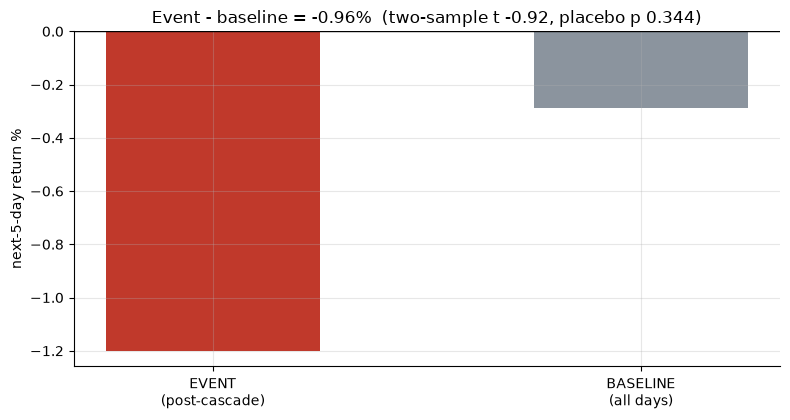

event -1.20% | baseline -0.29% | gap -0.96% | t -0.92 | placebo p 0.344 | n_event 74


In [2]:
es = st.event_study(FRAME_NULL, horizon=HORIZON, q=Q)
p = st.placebo_pvalue(FRAME_NULL, horizon=HORIZON, q=Q, n_perm=2000, seed=586)
em, bm, gap, t = es['event_mean']*100, es['baseline_mean']*100, es['gap']*100, es['t']
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(['EVENT\n(post-cascade)', 'BASELINE\n(all days)'], [em, bm], color=[RED, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel(f'next-{HORIZON}-day return %')
ax.set_title(f'Event - baseline = {gap:+.2f}%  (two-sample t {t:+.2f}, placebo p {p:.3f})')
plt.tight_layout(); plt.show()
print(f'event {em:+.2f}% | baseline {bm:+.2f}% | gap {gap:+.2f}% | t {t:+.2f} | placebo p {p:.3f}'
      f' | n_event {es["n_event"]}')

> 💡 In plain words: H₁ **not met** — the post-cascade gap is **-0.96%** (*t* -0.92), the *wrong* sign, and the placebo *p* = 0.34 says it's indistinguishable from noise. No capitulation-bounce in the null world.

### 4b · Robustness — H₂ (does the sign hold?)

The event−baseline gap and its *t* across every horizon × threshold.

 horizon      q  gap_pct      t  n_event
       1 top 9%   -0.398 -1.059      139
       1 top 5%   -0.644 -1.300       74
       1 top 1%    0.211  0.186       15
       3 top 9%   -0.346 -0.566      139
       3 top 5%    0.094  0.118       74
       3 top 1%    0.960  0.614       15
       5 top 9%   -1.099 -1.372      139
       5 top 5%   -0.957 -0.921       74
       5 top 1%    2.922  1.268       15
      10 top 9%   -1.454 -1.377      135
      10 top 5%   -0.703 -0.551       72
      10 top 1%   -0.321 -0.125       15
      20 top 9%   -1.685 -1.087      134
      20 top 5%   -0.941 -0.429       71
      20 top 1%   -1.480 -0.394       14


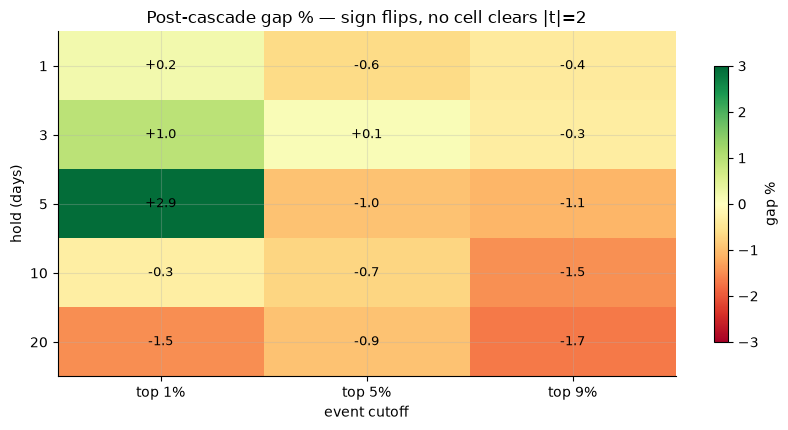

In [3]:
sw = st.robustness_sweep(FRAME_NULL, horizons=(1,3,5,10,20), quantiles=(0.90,0.95,0.99))
sw['q'] = sw['q'].map(lambda x: f'top {int((1-x)*100)}%')
print(sw.round(3).to_string(index=False))
piv = sw.pivot(index='horizon', columns='q', values='gap_pct')
fig, ax = plt.subplots(figsize=(8.5, 4.4))
im = ax.imshow(piv.values, cmap='RdYlGn', aspect='auto', vmin=-3, vmax=3)
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
ax.set_xlabel('event cutoff'); ax.set_ylabel('hold (days)')
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        ax.text(j, i, f'{piv.values[i,j]:+.1f}', ha='center', va='center', fontsize=9)
ax.set_title('Post-cascade gap % — sign flips, no cell clears |t|=2'); 
fig.colorbar(im, ax=ax, shrink=.8, label='gap %'); plt.tight_layout(); plt.show()

> 💡 In plain words: H₂ **rejected.** The gap flips sign across the grid and *no* cell reaches |*t*| ≥ 2. The lone strongly-positive cut (h=5, top 1%) rests on 15 events at *t* 1.27 — a curve-fit, not an edge.

## 5 · The verdict

- **Signal `NONE`** — H₀ binding (no free real tape → no `REAL`); H₁ not met in the null (gap -0.96%, *t* -0.92, wrong sign); H₂ rejected (sign flips, no |t| ≥ 2).
- **Tradability `MIRAGE`** — unreachable paid feed; wrong-signed headline gap; the best cut is a 15-event curve-fit; net of a 20 bps round-trip there is nothing to harvest.

## 6 · Could you trade it? — costs

The headline gap is the wrong sign before costs; even the single positive cut barely survives the round-trip and rests on a handful of events.

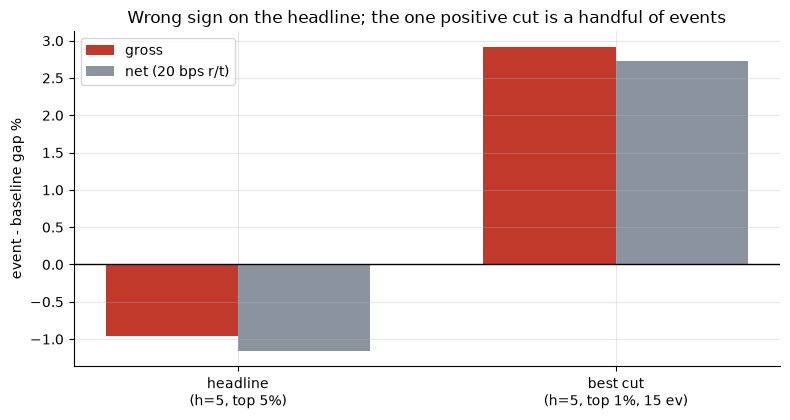

headline gross -0.96% -> net -1.16% | best-cut gross +2.92% -> net +2.72% (15 events)


In [4]:
es = st.event_study(FRAME_NULL, horizon=HORIZON, q=Q)
gap = es['gap']*100; net = st.net_gap(es['gap'], cost_bps=10.0)*100
# the 'best' curve-fit cut for contrast
esb = st.event_study(FRAME_NULL, horizon=5, q=0.99)
bgap = esb['gap']*100; bnet = st.net_gap(esb['gap'], cost_bps=10.0)*100
fig, ax = plt.subplots(figsize=(8, 4.3))
x = np.arange(2); w = .35
ax.bar(x-w/2, [gap, bgap], w, label='gross', color=RED)
ax.bar(x+w/2, [net, bnet], w, label='net (20 bps r/t)', color=GREY)
ax.set_xticks(x); ax.set_xticklabels(['headline\n(h=5, top 5%)', f'best cut\n(h=5, top 1%, {esb["n_event"]} ev)'])
ax.axhline(0, c='k', lw=1); ax.set_ylabel('event - baseline gap %'); ax.legend()
ax.set_title('Wrong sign on the headline; the one positive cut is a handful of events')
plt.tight_layout(); plt.show()
print(f'headline gross {gap:+.2f}% -> net {net:+.2f}% | best-cut gross {bgap:+.2f}% -> net {bnet:+.2f}% ({esb["n_event"]} events)')

> 💡 In plain words: nothing to charge costs against on the headline (it *loses* before frictions), and the positive cut is too thin to bank. `MIRAGE`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print ~0? Plant a real bounce (`bounce_alpha > 0`) of increasing strength and watch the event-study *t* rise — averaged over 25 seeds so no single lucky seed can fake it.

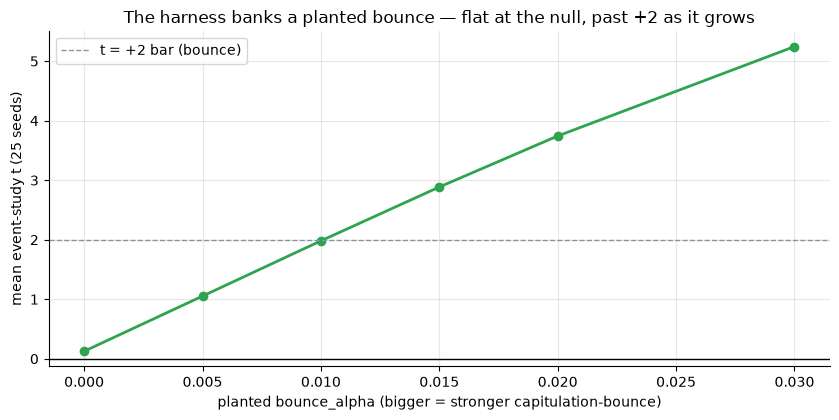

bounce_alpha +0.000 -> mean event-t +0.13
bounce_alpha +0.005 -> mean event-t +1.05
bounce_alpha +0.010 -> mean event-t +1.98
bounce_alpha +0.015 -> mean event-t +2.89
bounce_alpha +0.020 -> mean event-t +3.74
bounce_alpha +0.030 -> mean event-t +5.24


In [5]:
alphas = [0.0, 0.005, 0.010, 0.015, 0.020, 0.030]
ts = [st.synthetic_mean_t(data, bounce_alpha=a, horizon=HORIZON, q=Q, n_seeds=25) for a in alphas]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(alphas, ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = +2 bar (bounce)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted bounce_alpha (bigger = stronger capitulation-bounce)')
ax.set_ylabel('mean event-study t (25 seeds)')
ax.set_title('The harness banks a planted bounce — flat at the null, past +2 as it grows')
ax.legend(); plt.tight_layout(); plt.show()
for a, t in zip(alphas, ts): print(f'bounce_alpha {a:+.3f} -> mean event-t {t:+.2f}')

The event-*t* is ≈ 0 at the null (no hallucinated bounce) and climbs past +2 as the planted bounce grows — a faithful detector. So the null-world result is a statement about *a world where liquidations carry no forward information*, and the real-data verdict is gated entirely by **H₀**: no free forced-liquidation tape exists, so the honest stamp is `NONE` × `MIRAGE`. Point the engine at a paid Coinglass/Amberdata feed (the seam in `data.py`) and it will tell you, honestly, whether the bounce is there.